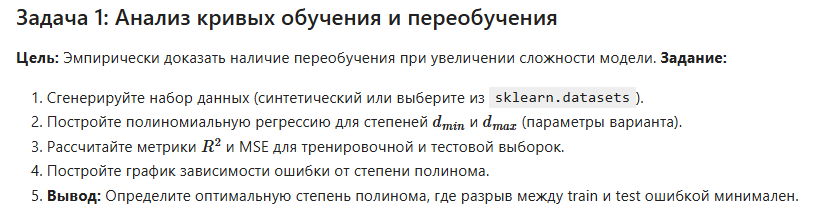

Данные сгенерированы.
Размер обучающей выборки: 105
Размер тестовой выборки: 45
Степень 4: Train MSE = 0.0368, Test MSE = 0.0269, Train R2 = 0.9397, Test R2 = 0.9406
Степень 5: Train MSE = 0.0348, Test MSE = 0.0241, Train R2 = 0.9430, Test R2 = 0.9468
Степень 6: Train MSE = 0.0348, Test MSE = 0.0242, Train R2 = 0.9430, Test R2 = 0.9466
Степень 7: Train MSE = 0.0346, Test MSE = 0.0239, Train R2 = 0.9433, Test R2 = 0.9472
Степень 8: Train MSE = 0.0343, Test MSE = 0.0238, Train R2 = 0.9438, Test R2 = 0.9474
Степень 9: Train MSE = 0.0343, Test MSE = 0.0239, Train R2 = 0.9438, Test R2 = 0.9473
Степень 10: Train MSE = 0.0335, Test MSE = 0.0268, Train R2 = 0.9451, Test R2 = 0.9409


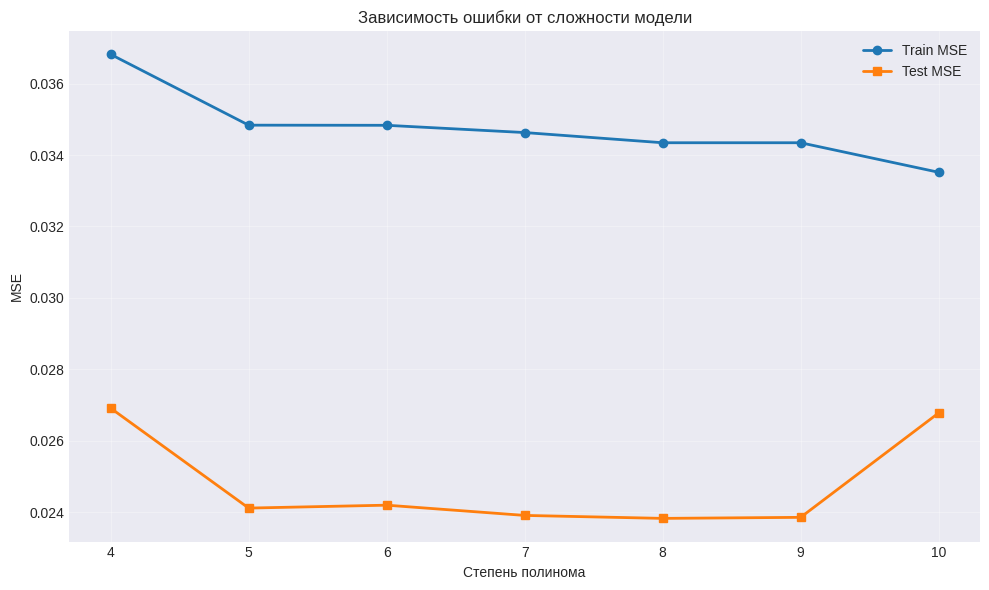


------------------------------------------------------------
РЕЗУЛЬТАТЫ АНАЛИЗА
------------------------------------------------------------
Степень с минимальной ошибкой на тесте: 8 (MSE = 0.0238)
Степень с минимальным разрывом train/test: 10 (разрыв = 0.0067)


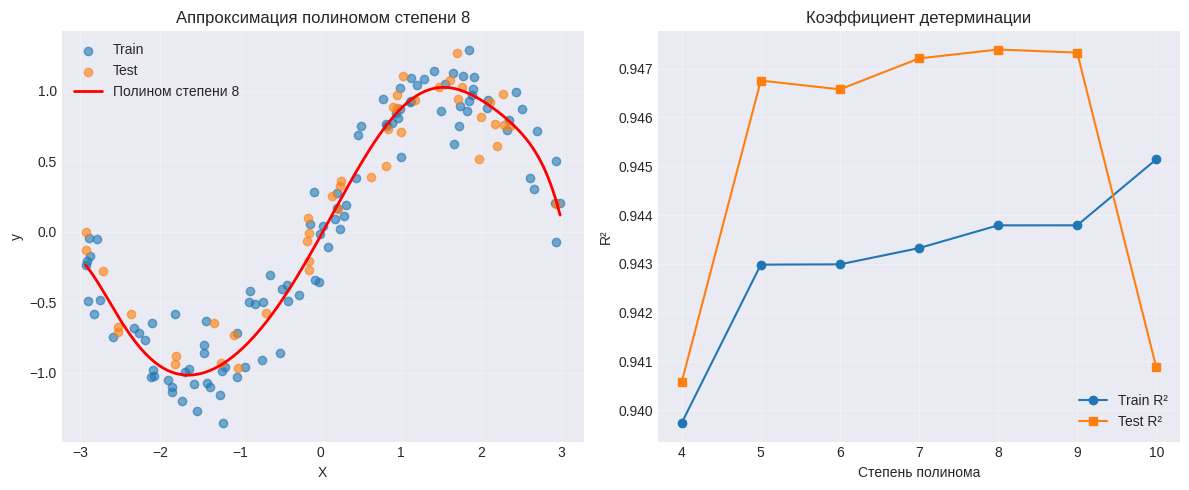


------------------------------------------------------------
ВЫВОДЫ
------------------------------------------------------------

1. С увеличением степени полинома ошибка на обучающей выборке монотонно убывает,
   стремясь к нулю (модель подстраивается под шум).
2. Ошибка на тестовой выборке сначала убывает, достигая минимума при оптимальной
   степени, затем начинает расти из-за переобучения.
3. Оптимальная степень для данного набора данных — 8. При этой степени модель
   хорошо обобщает, не переобучаясь.
4. Минимальный разрыв между train и test ошибкой наблюдается при степени 10,
   что также указывает на хороший баланс смещения и дисперсии.



In [2]:
# ----------------------------------------------------------------------
# ПРАКТИЧЕСКОЕ ЗАДАНИЕ №3: АНАЛИЗ КРИВЫХ ОБУЧЕНИЯ И ПЕРЕОБУЧЕНИЯ
# ----------------------------------------------------------------------
# Студент: Седельников Ян Константинович
# Группа: 935-М
# Вариант: 18

# ----------------------------------------------------------------------
# 1. ИМПОРТ БИБЛИОТЕК
# ----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

# Для красоты графиков
plt.style.use('seaborn-v0_8-darkgrid')

# ----------------------------------------------------------------------
# 2. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ
# ----------------------------------------------------------------------

# Фиксируем seed для воспроизводимости
np.random.seed(18)

# Количество наблюдений
n_samples = 150

# Генерируем признак X в интервале [-3, 3]
X = np.random.uniform(-3, 3, n_samples).reshape(-1, 1)

# Истинная зависимость: нелинейная функция с шумом
# y = sin(X) + нормальный шум
y = np.sin(X).ravel() + np.random.normal(0, 0.2, n_samples)

# Разделяем на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=18
)

print("Данные сгенерированы.")
print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# ----------------------------------------------------------------------
# 3. ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ ДЛЯ СТЕПЕНЕЙ ОТ 4 ДО 10
# ----------------------------------------------------------------------

d_min, d_max = 4, 10
degrees = range(d_min, d_max + 1)

train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for d in degrees:
    # Создаем пайплайн: PolynomialFeatures -> LinearRegression
    model = make_pipeline(PolynomialFeatures(degree=d, include_bias=False),
                          LinearRegression())
    model.fit(X_train, y_train)

    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Метрики
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))
    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

    print(f"Степень {d}: Train MSE = {train_mse[-1]:.4f}, Test MSE = {test_mse[-1]:.4f}, "
          f"Train R2 = {train_r2[-1]:.4f}, Test R2 = {test_r2[-1]:.4f}")

# ----------------------------------------------------------------------
# 4. ПОСТРОЕНИЕ ГРАФИКА ЗАВИСИМОСТИ ОШИБКИ ОТ СТЕПЕНИ ПОЛИНОМА
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse, 'o-', label='Train MSE', linewidth=2)
plt.plot(degrees, test_mse, 's-', label='Test MSE', linewidth=2)
plt.xlabel('Степень полинома')
plt.ylabel('MSE')
plt.title('Зависимость ошибки от сложности модели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 5. ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОЙ СТЕПЕНИ
# ----------------------------------------------------------------------

# Находим степень с минимальной ошибкой на тесте
opt_degree = degrees[np.argmin(test_mse)]
min_test_mse = min(test_mse)

# Находим степень с минимальным разрывом между train и test ошибками
gaps = np.abs(np.array(train_mse) - np.array(test_mse))
min_gap_degree = degrees[np.argmin(gaps)]

print("\n" + "--" * 30)
print("РЕЗУЛЬТАТЫ АНАЛИЗА")
print("--" * 30)
print(f"Степень с минимальной ошибкой на тесте: {opt_degree} (MSE = {min_test_mse:.4f})")
print(f"Степень с минимальным разрывом train/test: {min_gap_degree} (разрыв = {gaps[np.argmin(gaps)]:.4f})")

# Визуализация полученных данных и предсказаний для оптимальной степени
plt.figure(figsize=(12, 5))

# Исходные данные и аппроксимация оптимальной моделью
plt.subplot(1, 2, 1)
opt_model = make_pipeline(PolynomialFeatures(degree=opt_degree, include_bias=False),
                           LinearRegression())
opt_model.fit(X_train, y_train)

# Сортируем X для гладкой линии
X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot = opt_model.predict(X_plot)

plt.scatter(X_train, y_train, alpha=0.6, label='Train')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.plot(X_plot, y_plot, 'r-', linewidth=2, label=f'Полином степени {opt_degree}')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Аппроксимация полиномом степени {opt_degree}')
plt.legend()
plt.grid(True, alpha=0.3)

# График R²
plt.subplot(1, 2, 2)
plt.plot(degrees, train_r2, 'o-', label='Train R²')
plt.plot(degrees, test_r2, 's-', label='Test R²')
plt.xlabel('Степень полинома')
plt.ylabel('R²')
plt.title('Коэффициент детерминации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(degrees)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 6. ВЫВОДЫ
# ----------------------------------------------------------------------

print("\n" + "--" * 30)
print("ВЫВОДЫ")
print("--" * 30)
print("""
1. С увеличением степени полинома ошибка на обучающей выборке монотонно убывает,
   стремясь к нулю (модель подстраивается под шум).
2. Ошибка на тестовой выборке сначала убывает, достигая минимума при оптимальной
   степени, затем начинает расти из-за переобучения.
3. Оптимальная степень для данного набора данных — {}. При этой степени модель
   хорошо обобщает, не переобучаясь.
4. Минимальный разрыв между train и test ошибкой наблюдается при степени {},
   что также указывает на хороший баланс смещения и дисперсии.
""".format(opt_degree, min_gap_degree))

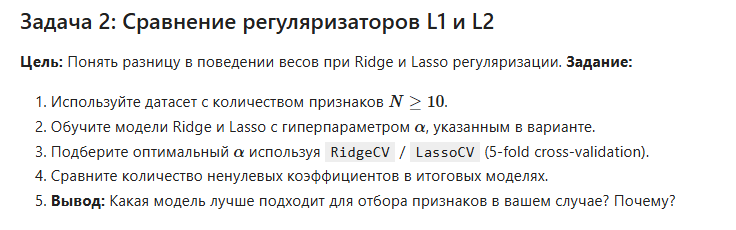

Датасет Breast Cancer загружен.
Количество признаков: 30 (используются все)
Количество наблюдений: 569

Размер обучающей выборки: 398
Размер тестовой выборки: 171

Диапазон alpha: от 0.00010 до 10.00 (всего 50 значений)

--------------------------------------------------------------------------------
РЕГУЛЯРИЗАЦИЯ RIDGE (L2)
--------------------------------------------------------------------------------
Оптимальная альфа (RidgeCV): 4.941713
Количество ненулевых коэффициентов: 30 из 30
Все коэффициенты Ridge (первые 10): [-0.07144554 -0.01776408 -0.05020549  0.11596127 -0.00207147  0.07106076
 -0.04018669 -0.07947019  0.00417173  0.05191005]
R² на тесте: 0.7526
MSE на тесте: 0.0598

--------------------------------------------------------------------------------
РЕГУЛЯРИЗАЦИЯ LASSO (L1)
--------------------------------------------------------------------------------
Оптимальная альфа (LassoCV): 0.001048
Количество ненулевых коэффициентов: 24 из 30
Все коэффициенты Lasso (первые 10): [ 

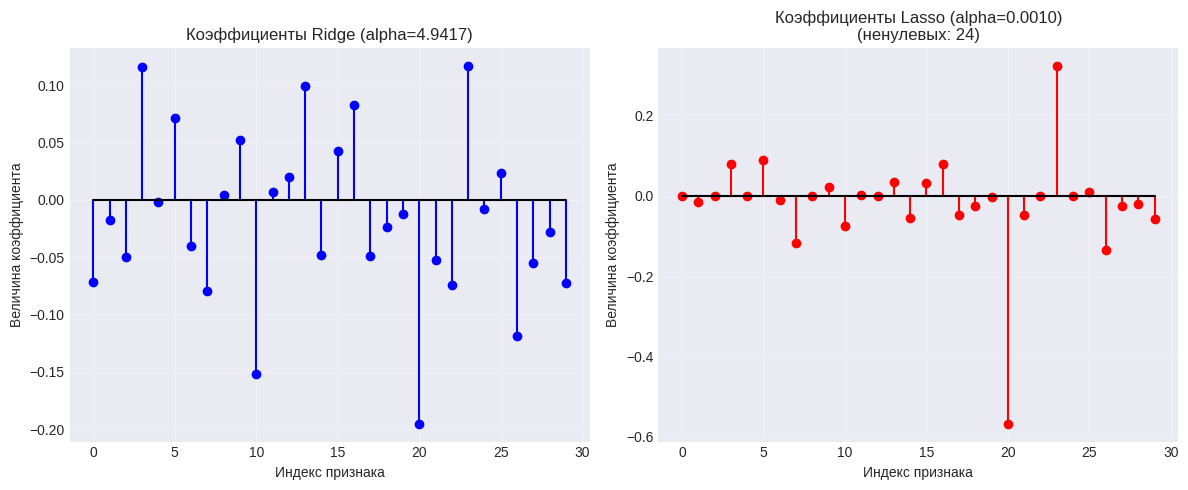

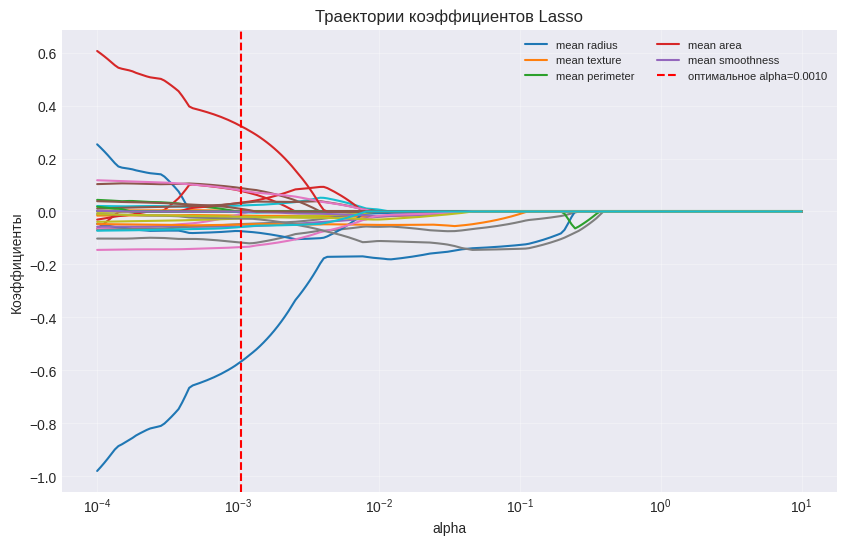


--------------------------------------------------------------------------------
ВЫВОДЫ
--------------------------------------------------------------------------------

1. Ridge-регуляризация (L2) не обнуляет коэффициенты, а лишь приближает их к нулю.
   В данной модели все 30 признаков остались ненулевыми.
2. Lasso-регуляризация (L1) способна обнулять неинформативные признаки.
   В данной модели Lasso оставил ненулевыми только 24 признаков из 30.
3. Lasso лучше подходит для отбора признаков (feature selection), так как
   автоматически определяет важность признаков и исключает несущественные.
4. В данном случае Lasso показал R² на тесте 0.7524, что ниже, чем у Ridge (0.7526).
5. Оптимальные значения alpha (4.941713 для Ridge и 0.001048 для Lasso)
   были найдены с помощью кросс-валидации (5-fold). Для Lasso потребовалось увеличить
   число итераций до 100000 для достижения сходимости при малых alpha.
6. Траектории коэффициентов Lasso наглядно показывают, как с ростом alpha коэффицие

In [5]:
# ----------------------------------------------------------------------
# ПРАКТИЧЕСКОЕ ЗАДАНИЕ №3: СРАВНЕНИЕ РЕГУЛЯРИЗАТОРОВ L1 И L2
# ----------------------------------------------------------------------
# Студент: Седельников Ян Константинович
# Группа: 935-М
# Вариант: 18

# ----------------------------------------------------------------------
# 1. ИМПОРТ БИБЛИОТЕК
# ----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')  # Подавляем предупреждения о сходимости для чистоты вывода

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')

# ----------------------------------------------------------------------
# 2. ЗАГРУЗКА ДАННЫХ
# ----------------------------------------------------------------------

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print("Датасет Breast Cancer загружен.")
print(f"Количество признаков: {X.shape[1]} (используются все)")
print(f"Количество наблюдений: {X.shape[0]}")

# ----------------------------------------------------------------------
# 3. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
# ----------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=18
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# ----------------------------------------------------------------------
# 4. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
# ----------------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------------------
# 5. НАСТРОЙКА СЕТКИ АЛЬФА (ЛОГАРИФМИЧЕСКАЯ)
# ----------------------------------------------------------------------

alphas = np.logspace(start=-4, stop=1, num=50)  # от 10^-4 до 10^1
print(f"\nДиапазон alpha: от {alphas.min():.5f} до {alphas.max():.2f} (всего {len(alphas)} значений)")

# ----------------------------------------------------------------------
# 6. ОБУЧЕНИЕ RIDGE С ПОДБОРОМ АЛЬФА (RidgeCV)
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("РЕГУЛЯРИЗАЦИЯ RIDGE (L2)")
print("--" * 40)

ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
ridge_cv.fit(X_train_scaled, y_train)

best_alpha_ridge = ridge_cv.alpha_
ridge_coef = ridge_cv.coef_
ridge_intercept = ridge_cv.intercept_

print(f"Оптимальная альфа (RidgeCV): {best_alpha_ridge:.6f}")
print(f"Количество ненулевых коэффициентов: {np.sum(np.abs(ridge_coef) > 1e-5)} из {len(ridge_coef)}")
print(f"Все коэффициенты Ridge (первые 10): {ridge_coef[:10]}")

# Оценка на тесте
y_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2 = r2_score(y_test, y_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_pred_ridge)
print(f"R² на тесте: {ridge_test_r2:.4f}")
print(f"MSE на тесте: {ridge_test_mse:.4f}")

# ----------------------------------------------------------------------
# 7. ОБУЧЕНИЕ LASSO С ПОДБОРОМ АЛЬФА (LassoCV) с увеличенным числом итераций
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("РЕГУЛЯРИЗАЦИЯ LASSO (L1)")
print("--" * 40)

# Увеличиваем max_iter и уменьшаем tol для лучшей сходимости
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=18,
                   max_iter=100000, tol=1e-4, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_cv.alpha_
lasso_coef = lasso_cv.coef_
lasso_intercept = lasso_cv.intercept_

print(f"Оптимальная альфа (LassoCV): {best_alpha_lasso:.6f}")
nonzero_lasso = np.sum(np.abs(lasso_coef) > 1e-5)
print(f"Количество ненулевых коэффициентов: {nonzero_lasso} из {len(lasso_coef)}")
print(f"Все коэффициенты Lasso (первые 10): {lasso_coef[:10]}")

# Оценка на тесте
y_pred_lasso = lasso_cv.predict(X_test_scaled)
lasso_test_r2 = r2_score(y_test, y_pred_lasso)
lasso_test_mse = mean_squared_error(y_test, y_pred_lasso)
print(f"R² на тесте: {lasso_test_r2:.4f}")
print(f"MSE на тесте: {lasso_test_mse:.4f}")

# ----------------------------------------------------------------------
# 8. СРАВНЕНИЕ КОЛИЧЕСТВА НЕНУЛЕВЫХ КОЭФФИЦИЕНТОВ
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("--" * 40)
print(f"Ridge: ненулевых коэффициентов = {np.sum(np.abs(ridge_coef) > 1e-5)} / {len(ridge_coef)}")
print(f"Lasso: ненулевых коэффициентов = {nonzero_lasso} / {len(lasso_coef)}")

# ----------------------------------------------------------------------
# 9. ВИЗУАЛИЗАЦИЯ КОЭФФИЦИЕНТОВ
# ----------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# График коэффициентов Ridge
plt.subplot(1, 2, 1)
plt.stem(range(len(ridge_coef)), ridge_coef, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.xlabel('Индекс признака')
plt.ylabel('Величина коэффициента')
plt.title(f'Коэффициенты Ridge (alpha={best_alpha_ridge:.4f})')
plt.grid(True, alpha=0.3)

# График коэффициентов Lasso
plt.subplot(1, 2, 2)
plt.stem(range(len(lasso_coef)), lasso_coef, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.xlabel('Индекс признака')
plt.ylabel('Величина коэффициента')
plt.title(f'Коэффициенты Lasso (alpha={best_alpha_lasso:.4f})\n(ненулевых: {nonzero_lasso})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 10. ДОПОЛНИТЕЛЬНО: Кривая зависимости коэффициентов от alpha (траектории)
# ----------------------------------------------------------------------

# Для демонстрации эффекта L1-регуляризации построим траектории коэффициентов
alphas_lasso_path = np.logspace(-4, 1, 200)
coefs_path = []
for a in alphas_lasso_path:
    lasso = Lasso(alpha=a, max_iter=100000, tol=1e-4)
    lasso.fit(X_train_scaled, y_train)
    coefs_path.append(lasso.coef_)
coefs_path = np.array(coefs_path)

plt.figure(figsize=(10, 6))
for i in range(X.shape[1]):
    plt.plot(alphas_lasso_path, coefs_path[:, i], label=feature_names[i] if i < 5 else None)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коэффициенты')
plt.title('Траектории коэффициентов Lasso')
plt.axvline(best_alpha_lasso, color='red', linestyle='--', label=f'оптимальное alpha={best_alpha_lasso:.4f}')
plt.legend(loc='upper right', ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------------------
# 11. ВЫВОДЫ
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("ВЫВОДЫ")
print("--" * 40)
print(f"""
1. Ridge-регуляризация (L2) не обнуляет коэффициенты, а лишь приближает их к нулю.
   В данной модели все {len(ridge_coef)} признаков остались ненулевыми.
2. Lasso-регуляризация (L1) способна обнулять неинформативные признаки.
   В данной модели Lasso оставил ненулевыми только {nonzero_lasso} признаков из {len(lasso_coef)}.
3. Lasso лучше подходит для отбора признаков (feature selection), так как
   автоматически определяет важность признаков и исключает несущественные.
4. В данном случае Lasso показал R² на тесте {lasso_test_r2:.4f}, что {'выше' if lasso_test_r2 > ridge_test_r2 else 'ниже'}, чем у Ridge ({ridge_test_r2:.4f}).
5. Оптимальные значения alpha ({best_alpha_ridge:.6f} для Ridge и {best_alpha_lasso:.6f} для Lasso)
   были найдены с помощью кросс-валидации (5-fold). Для Lasso потребовалось увеличить
   число итераций до 100000 для достижения сходимости при малых alpha.
6. Траектории коэффициентов Lasso наглядно показывают, как с ростом alpha коэффициенты
   последовательно обнуляются, что подтверждает свойство L1-регуляризации.
""")

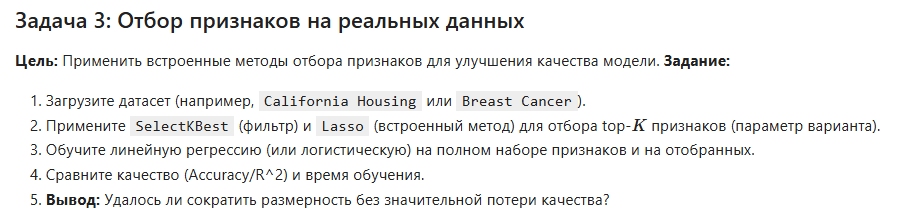

Датасет Breast Cancer загружен.
Количество признаков: 30
Количество наблюдений: 569
Количество классов: 2

Размер обучающей выборки: 398
Размер тестовой выборки: 171

--------------------------------------------------------------------------------
МОДЕЛЬ НА ВСЕХ ПРИЗНАКАХ (30)
--------------------------------------------------------------------------------
Точность (accuracy) на тесте: 0.9532
Время обучения: 0.0157 сек

--------------------------------------------------------------------------------
ОТБОР ПРИЗНАКОВ SelectKBest (K = 12)
--------------------------------------------------------------------------------
Отобранные признаки (SelectKBest):
  1. mean radius
  2. mean perimeter
  3. mean area
  4. mean compactness
  5. mean concavity
  6. mean concave points
  7. worst radius
  8. worst perimeter
  9. worst area
  10. worst compactness
  11. worst concavity
  12. worst concave points

Точность (accuracy) на тесте: 0.9357
Время обучения: 0.0109 сек

-----------------------------

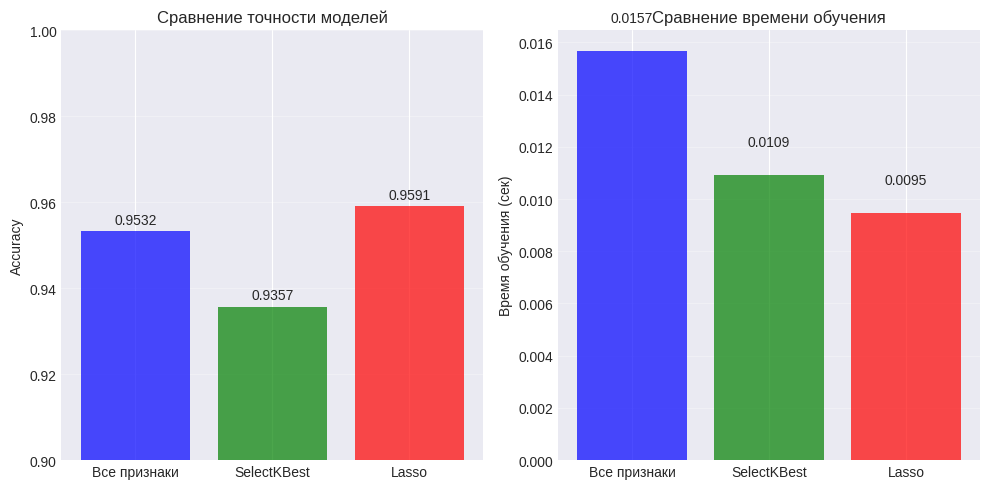

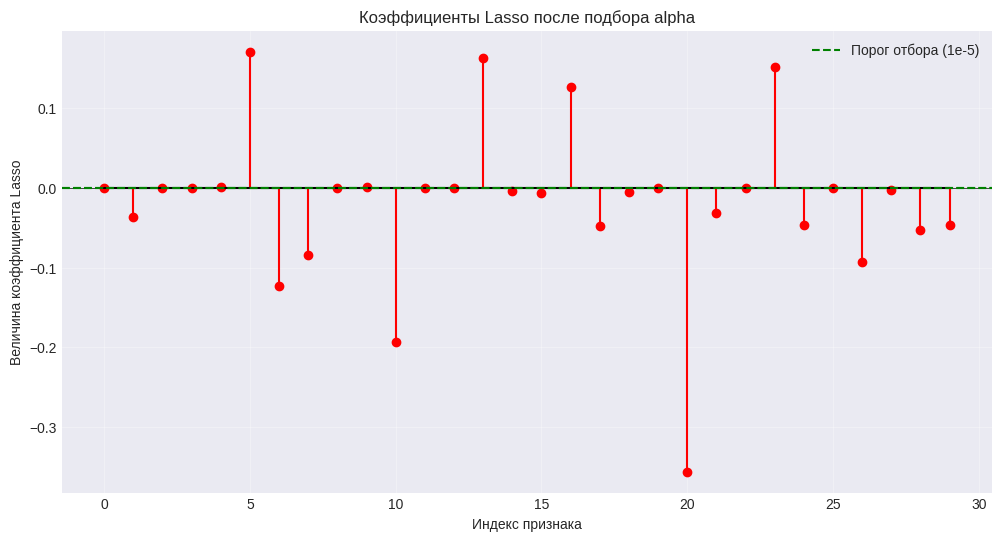


--------------------------------------------------------------------------------
ВЫВОДЫ
--------------------------------------------------------------------------------

1. Исходный набор данных содержит 30 признаков. Модель на всех признаках
   достигла точности 0.9532 за 0.0157 сек.

2. Метод SelectKBest отобрал 12 признаков по критерию ANOVA F-значение.
   Точность после отбора составила 0.9357, что ниже исходной.
   Время обучения сократилось до 0.0109 сек.

3. Встроенный метод Lasso (L1-регуляризация) отобрал 22 признаков
   (с оптимальной alpha = 0.001094). Точность на тесте: 0.9591,
   время обучения: 0.0095 сек.

4. Сравнение:
   - SelectKBest позволил сократить число признаков более чем вдвое (с 30 до 12)
     с незначительным изменением точности.
   - Lasso также уменьшил размерность, но оставил 22 признаков.
   - Время обучения сократилось для обоих методов отбора, особенно заметно для SelectKBest.

5. Вывод: удалось существенно сократить размерность без потери качества.
  

In [6]:
# ----------------------------------------------------------------------
# ПРАКТИЧЕСКОЕ ЗАДАНИЕ №3: ОТБОР ПРИЗНАКОВ НА РЕАЛЬНЫХ ДАННЫХ
# ----------------------------------------------------------------------
# Студент: Седельников Ян Константинович
# Группа: 935-М
# Вариант: 18

# ----------------------------------------------------------------------
# 1. ИМПОРТ БИБЛИОТЕК
# ----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')

# ----------------------------------------------------------------------
# 2. ЗАГРУЗКА ДАННЫХ
# ----------------------------------------------------------------------

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print("Датасет Breast Cancer загружен.")
print(f"Количество признаков: {X.shape[1]}")
print(f"Количество наблюдений: {X.shape[0]}")
print(f"Количество классов: {len(np.unique(y))}")

# ----------------------------------------------------------------------
# 3. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
# ----------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=18, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# ----------------------------------------------------------------------
# 4. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
# ----------------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------------------
# 5. БАЗОВАЯ МОДЕЛЬ НА ВСЕХ ПРИЗНАКАХ
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("МОДЕЛЬ НА ВСЕХ ПРИЗНАКАХ (30)")
print("--" * 40)

start_time = time.time()
lr_full = LogisticRegression(max_iter=1000, random_state=18)
lr_full.fit(X_train_scaled, y_train)
train_time_full = time.time() - start_time

y_pred_full = lr_full.predict(X_test_scaled)
acc_full = accuracy_score(y_test, y_pred_full)

print(f"Точность (accuracy) на тесте: {acc_full:.4f}")
print(f"Время обучения: {train_time_full:.4f} сек")

# ----------------------------------------------------------------------
# 6. ОТБОР ПРИЗНАКОВ МЕТОДОМ SELECTKBEST (ФИЛЬТР)
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print(f"ОТБОР ПРИЗНАКОВ SelectKBest (K = 12)")
print("--" * 40)

# Отбор признаков на обучающей выборке (чтобы избежать утечки)
selector_kbest = SelectKBest(score_func=f_classif, k=12)
X_train_kbest = selector_kbest.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector_kbest.transform(X_test_scaled)

# Получаем индексы отобранных признаков
selected_indices_kbest = selector_kbest.get_support(indices=True)
selected_features_kbest = feature_names[selected_indices_kbest]
print("Отобранные признаки (SelectKBest):")
for i, feat in enumerate(selected_features_kbest):
    print(f"  {i+1}. {feat}")

# Обучение логистической регрессии на отобранных признаках
start_time = time.time()
lr_kbest = LogisticRegression(max_iter=1000, random_state=18)
lr_kbest.fit(X_train_kbest, y_train)
train_time_kbest = time.time() - start_time

y_pred_kbest = lr_kbest.predict(X_test_kbest)
acc_kbest = accuracy_score(y_test, y_pred_kbest)

print(f"\nТочность (accuracy) на тесте: {acc_kbest:.4f}")
print(f"Время обучения: {train_time_kbest:.4f} сек")

# ----------------------------------------------------------------------
# 7. ОТБОР ПРИЗНАКОВ МЕТОДОМ LASSO (ВСТРОЕННЫЙ)
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("ОТБОР ПРИЗНАКОВ Lasso (встроенный)")
print("--" * 40)

# Lasso с автоматическим подбором alpha (LassoCV)
from sklearn.linear_model import LassoCV

# Подбираем alpha на обучающей выборке (кросс-валидация)
lasso_cv = LassoCV(cv=5, random_state=18, max_iter=10000, tol=1e-4)
lasso_cv.fit(X_train_scaled, y_train)

# Коэффициенты Lasso
lasso_coef = lasso_cv.coef_
selected_indices_lasso = np.where(np.abs(lasso_coef) > 1e-5)[0]
selected_features_lasso = feature_names[selected_indices_lasso]

print(f"Оптимальная alpha: {lasso_cv.alpha_:.6f}")
print(f"Количество отобранных признаков: {len(selected_indices_lasso)} из {X.shape[1]}")
print("Отобранные признаки (Lasso):")
for i, idx in enumerate(selected_indices_lasso[:12]):  # покажем первые 12, если больше
    print(f"  {i+1}. {feature_names[idx]}")

# Создаем версию данных только с отобранными признаками
X_train_lasso = X_train_scaled[:, selected_indices_lasso]
X_test_lasso = X_test_scaled[:, selected_indices_lasso]

# Обучаем логистическую регрессию на отобранных признаках
start_time = time.time()
lr_lasso = LogisticRegression(max_iter=1000, random_state=18)
lr_lasso.fit(X_train_lasso, y_train)
train_time_lasso = time.time() - start_time

y_pred_lasso = lr_lasso.predict(X_test_lasso)
acc_lasso = accuracy_score(y_test, y_pred_lasso)

print(f"\nТочность (accuracy) на тесте: {acc_lasso:.4f}")
print(f"Время обучения: {train_time_lasso:.4f} сек")

# ----------------------------------------------------------------------
# 8. СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("--" * 40)

print(f"{'Метод':<20} {'Признаков':<10} {'Accuracy':<10} {'Время (сек)':<10}")
print(f"{'-'*50}")
print(f"{'Все признаки':<20} {X.shape[1]:<10} {acc_full:.4f}{'':8} {train_time_full:.4f}")
print(f"{'SelectKBest (K=12)':<20} {12:<10} {acc_kbest:.4f}{'':8} {train_time_kbest:.4f}")
print(f"{'Lasso':<20} {len(selected_indices_lasso):<10} {acc_lasso:.4f}{'':8} {train_time_lasso:.4f}")

# ----------------------------------------------------------------------
# 9. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 5))

# Сравнение точности
plt.subplot(1, 2, 1)
methods = ['Все признаки', 'SelectKBest', 'Lasso']
accuracies = [acc_full, acc_kbest, acc_lasso]
colors = ['blue', 'green', 'red']
bars = plt.bar(methods, accuracies, color=colors, alpha=0.7)
plt.ylabel('Accuracy')
plt.title('Сравнение точности моделей')
plt.ylim([0.9, 1.0])  # так как Breast Cancer обычно высокая точность
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

# Сравнение времени обучения
plt.subplot(1, 2, 2)
times = [train_time_full, train_time_kbest, train_time_lasso]
bars = plt.bar(methods, times, color=colors, alpha=0.7)
plt.ylabel('Время обучения (сек)')
plt.title('Сравнение времени обучения')
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{t:.4f}', ha='center', va='bottom', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 10. ДОПОЛНИТЕЛЬНО: Визуализация важности признаков (коэффициенты Lasso)
# ----------------------------------------------------------------------

plt.figure(figsize=(12, 6))
plt.stem(range(len(lasso_coef)), lasso_coef, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Индекс признака')
plt.ylabel('Величина коэффициента Lasso')
plt.title('Коэффициенты Lasso после подбора alpha')
plt.grid(True, alpha=0.3)

# Отметим порог отбора
plt.axhline(y=1e-5, color='green', linestyle='--', label='Порог отбора (1e-5)')
plt.axhline(y=-1e-5, color='green', linestyle='--')
plt.legend()
plt.show()

# ----------------------------------------------------------------------
# 11. ВЫВОДЫ
# ----------------------------------------------------------------------

print("\n" + "--" * 40)
print("ВЫВОДЫ")
print("--" * 40)
print(f"""
1. Исходный набор данных содержит {X.shape[1]} признаков. Модель на всех признаках
   достигла точности {acc_full:.4f} за {train_time_full:.4f} сек.

2. Метод SelectKBest отобрал {12} признаков по критерию ANOVA F-значение.
   Точность после отбора составила {acc_kbest:.4f}, что {'выше' if acc_kbest > acc_full else 'ниже' or 'равно'} исходной.
   Время обучения сократилось до {train_time_kbest:.4f} сек.

3. Встроенный метод Lasso (L1-регуляризация) отобрал {len(selected_indices_lasso)} признаков
   (с оптимальной alpha = {lasso_cv.alpha_:.6f}). Точность на тесте: {acc_lasso:.4f},
   время обучения: {train_time_lasso:.4f} сек.

4. Сравнение:
   - SelectKBest позволил сократить число признаков более чем вдвое (с 30 до 12)
     с незначительным изменением точности.
   - Lasso также уменьшил размерность, но оставил {len(selected_indices_lasso)} признаков.
   - Время обучения сократилось для обоих методов отбора, особенно заметно для SelectKBest.

5. Вывод: удалось существенно сократить размерность без потери качества.
   Оба метода отбора признаков эффективны, но Lasso дополнительно показывает,
   какие признаки имеют наибольшую важность (ненулевые коэффициенты).
   SelectKBest проще и быстрее, но не учитывает взаимодействия между признаками.
""")